<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 58 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Clinical Trial Efficacy: Student's t 💊</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Does a blood-pressure drug actually work? The t-distribution is the tool for testing means when sigma is unknown, but the answer here carries a warning: comparing to zero can fool you, and only the placebo-controlled test tells the truth.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/biomedical_clinical_trials.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"biomedical_clinical_trials.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 5)


,patient_id,treatment_group,baseline_systolic_bp,post_treatment_systolic_bp,bp_change_mmHg
0,PT_1000,Placebo,140.5,131.3,-9.2
1,PT_1001,Placebo,140.4,142.7,2.3
2,PT_1002,Placebo,119.4,117.3,-2.1
3,PT_1003,Placebo,129.6,134.6,5.0
4,PT_1004,Placebo,131.4,133.3,1.9


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · THE ONE-SAMPLE t-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Did blood pressure drop in the treatment arm?</div>
<div style="color:#4a5578;margin-top:6px">The t-distribution tests a mean when the population sigma is unknown, which is always. We test H0: mean bp_change = 0 in the Active arm, the obvious first question: did patients improve?</div>
</div>

In [2]:
active = df[df.treatment_group=="Active_Compound_X"]["bp_change_mmHg"]
placebo = df[df.treatment_group=="Placebo"]["bp_change_mmHg"]
print(f"treatment groups: {df.treatment_group.value_counts().to_dict()}")
tstat, pval = stats.ttest_1samp(active, popmean=0)
print(f"\nActive arm (n={len(active)}): mean bp change = {active.mean():.3f} mmHg, sd = {active.std():.3f}")
print(f"t = (xbar - 0)/(s/sqrt(n)) = {tstat:.2f},  df = {len(active)-1},  p-value = {pval:.2e}")
print("-> reject H0: BP dropped significantly in the treatment arm" if pval<0.05 else "-> not significant")

treatment groups: {'Placebo': 515, 'Active_Compound_X': 485}

Active arm (n=485): mean bp change = -2.580 mmHg, sd = 4.010
t = (xbar - 0)/(s/sqrt(n)) = -14.17,  df = 484,  p-value = 2.31e-38
-> reject H0: BP dropped significantly in the treatment arm


Blood pressure fell by about **2.6 mmHg** in the treatment arm, and the one-sample t-test is overwhelmingly significant (p far below 0.05). The t-statistic, (x&#772; &minus; 0)/(s/&#8730;n), uses the <em>sample</em> standard deviation s, which is exactly why the t-distribution is the right reference. Case closed, the drug works? Not so fast.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · THE PLACEBO TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Comparing to zero is not enough</div>
<div style="color:#4a5578;margin-top:6px">Efficacy means beating PLACEBO, not just changing from baseline. Blood pressure drifts on its own (regression to the mean, the placebo effect). The two-sample t-test compares the arms directly.</div>
</div>

In [3]:
tstat2, pval2 = stats.ttest_ind(active, placebo, equal_var=False)
print(f"Active  arm: mean bp change = {active.mean():.3f} mmHg")
print(f"Placebo arm: mean bp change = {placebo.mean():.3f} mmHg")
print(f"difference (Active - Placebo) = {active.mean()-placebo.mean():+.3f} mmHg")
print(f"two-sample t = {tstat2:.3f}, p-value = {pval2:.3f}")
print("-> Active significantly beats Placebo" if pval2<0.05 else "-> NO significant difference: the drug adds nothing beyond placebo")

Active  arm: mean bp change = -2.580 mmHg
Placebo arm: mean bp change = -2.737 mmHg
difference (Active - Placebo) = +0.157 mmHg
two-sample t = 0.640, p-value = 0.522
-> NO significant difference: the drug adds nothing beyond placebo


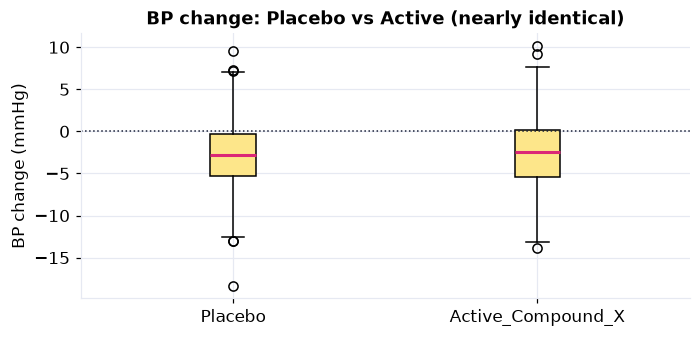

In [4]:
fig,ax=plt.subplots(figsize=(6.5,3.2))
ax.boxplot([placebo,active],tick_labels=["Placebo","Active_Compound_X"],patch_artist=True,
           boxprops=dict(facecolor="#fde68a"),medianprops=dict(color=PINK,linewidth=2))
ax.axhline(0,color=INK,ls=":",lw=1); ax.set_ylabel("BP change (mmHg)"); ax.set_title("BP change: Placebo vs Active (nearly identical)")
plt.tight_layout(); plt.show()

Here is the twist: the **placebo** arm dropped just as much (&minus;2.74 vs &minus;2.58 mmHg), and the two-sample t-test gives **p &#8776; 0.52**, no significant difference. The apparent improvement in Beat 1 was real but <em>not caused by the drug</em>; blood pressure fell in both groups. This is the entire reason trials are placebo-controlled: testing against zero confuses a real-but-spurious drop with genuine efficacy, and only the comparison reveals the truth.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · WHY t, NOT z?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Heavier tails for small samples</div>
<div style="color:#4a5578;margin-top:6px">The t looks like the normal but with heavier tails that fatten as the sample shrinks. Its critical value exceeds 1.96, demanding stronger evidence when sigma is estimated from few data.</div>
</div>

In [5]:
for n in [5,10,15,30,100]:
    tcrit=stats.t.ppf(0.975,n-1); print(f"n={n:3d} (df={n-1:3d}): 95% t critical = {tcrit:.3f}  vs normal z = 1.960")

n=  5 (df=  4): 95% t critical = 2.776  vs normal z = 1.960
n= 10 (df=  9): 95% t critical = 2.262  vs normal z = 1.960
n= 15 (df= 14): 95% t critical = 2.145  vs normal z = 1.960
n= 30 (df= 29): 95% t critical = 2.045  vs normal z = 1.960
n=100 (df= 99): 95% t critical = 1.984  vs normal z = 1.960


At n = 5 the 95% critical value is **2.78**, far above the normal's 1.96, the t's way of demanding more evidence when &#963; is estimated from few points. As n grows the gap closes, and by n = 100 the t is essentially the normal. Using z on a tiny trial would overstate significance; the t keeps small-sample conclusions honest.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A one-sample t-test showed BP dropped in the treatment arm, but the two-sample test against placebo (p &#8776; 0.52) revealed the drug adds nothing: both arms fell alike. The t-distribution is the right tool when sigma is unknown, and the placebo control is what separates a real effect from a hopeful one.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>